In [1]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

In [2]:
df=pd.read_csv("marketing_AB.csv")

In [3]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Unnamed: 0     588101 non-null  int64
 1   user id        588101 non-null  int64
 2   test group     588101 non-null  str  
 3   converted      588101 non-null  bool 
 4   total ads      588101 non-null  int64
 5   most ads day   588101 non-null  str  
 6   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(4), str(2)
memory usage: 27.5 MB


In [5]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [6]:
df['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [7]:
df.groupby('test group')['converted'].mean()

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

In [8]:
ad_group = df[df['test group']=='ad']
psa_group = df[df['test group']=='psa']

In [9]:
converted = True

In [10]:
success=[
      ad_group['converted'].sum(),
      psa_group['converted'].sum()
]
success

[np.int64(14423), np.int64(420)]

In [11]:
nb =[
    ad_group.shape[0],
    psa_group.shape[0]
]
nb

[564577, 23524]

In [13]:
z_stat,p_value=proportions_ztest(success,nb)
print("z-STATISTICS", z_stat)
print("p-value",p_value)

z-STATISTICS 7.3700781265454145
p-value 1.7052807161559727e-13


In [15]:
alpha = 0.05
if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to reject Null Hypothesis")

Reject Null Hypothesis


## ADD VISUALIZATIONS

In [16]:
import matplotlib.pyplot as plt

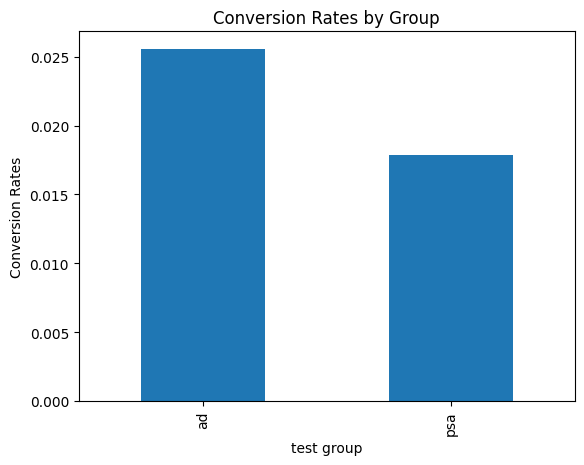

In [17]:
conversion_rates = df.groupby('test group')['converted'].mean()
conversion_rates.plot(kind ='bar')
plt.title("Conversion Rates by Group")
plt.ylabel("Conversion Rates")
plt.show()